In [1]:
import pandas as pd
import numpy as np

import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import shap

import joblib

In [2]:
master = pd.read_parquet(
    "../data/master/master_clustered.parquet"
)

master.shape

(632, 64)

In [3]:
master["tier"].value_counts()

tier
Tier II - Strong Performing Districts         198
Tier IV - Improvement Potential Districts     159
Tier I - High Impact Districts                157
Tier III - Inclusive Development Districts     92
Tier V - Special Challenge Districts           17
Name: count, dtype: int64

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

master["tier_encoded"] = (
    le.fit_transform(
        master["tier"]
    )
)

In [5]:
dict(
    zip(
        le.classes_,
        le.transform(le.classes_)
    )
)

{'Tier I - High Impact Districts': np.int64(0),
 'Tier II - Strong Performing Districts': np.int64(1),
 'Tier III - Inclusive Development Districts': np.int64(2),
 'Tier IV - Improvement Potential Districts': np.int64(3),
 'Tier V - Special Challenge Districts': np.int64(4),
 nan: np.int64(5)}

In [6]:
features = [
    "female_literacy_pct",
    "scst_pct",
    "agri_worker_pct",
    "poverty_log",
    "night_lights_log",

    "wage_timeliness_pct",
    "avg_days_per_hh",
    "women_pct",
    "persondays_per_hh"
]

In [7]:
model_df = (
    master[
        features
        + ["tier_encoded"]
    ]
    .dropna()
    .copy()
)

model_df.shape

(623, 10)

In [8]:
X = model_df[features]

y = model_df["tier_encoded"]

In [9]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

In [10]:
model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=5,

    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42
)

In [11]:
model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [12]:
y_pred = model.predict(
    X_test
)

accuracy_score(
    y_test,
    y_pred
)

0.76

In [13]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.81      0.84        32
           1       0.72      0.82      0.77        40
           2       0.95      1.00      0.97        18
           3       0.56      0.47      0.51        32
           4       1.00      1.00      1.00         3

    accuracy                           0.76       125
   macro avg       0.82      0.82      0.82       125
weighted avg       0.75      0.76      0.75       125



In [14]:
confusion_matrix(
    y_test,
    y_pred
)

array([[26,  0,  0,  6,  0],
       [ 1, 33,  0,  6,  0],
       [ 0,  0, 18,  0,  0],
       [ 3, 13,  1, 15,  0],
       [ 0,  0,  0,  0,  3]])

Silhouette ≈ 0.26
ARI ≈ 0.41
XGBoost Accuracy ≈ 0.76

✓ Clusters are not random
✓ Governance archetypes exist
✓ Features explain cluster membership well
✓ Tier framework is usable

Why did a district become
High Impact?

Why did it become
Special Challenge?

Why did it become
Inclusive Development?

In [55]:
explainer = shap.TreeExplainer(model)

X_full = model_df[features]

shap_values_full = explainer.shap_values(X_full)

In [56]:
type(shap_values_full)

numpy.ndarray

In [57]:
np.array(shap_values_full).shape

(623, 9, 5)

In [58]:
import numpy as np

feature_importance = np.abs(
    shap_values_full
).mean(axis=(0, 2))

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": feature_importance
})

importance_df = (
    importance_df
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
)

importance_df

,feature,mean_abs_shap
7,women_pct,0.830972
6,avg_days_per_hh,0.739300
8,persondays_per_hh,0.566975
5,wage_timeliness_pct,0.539622
3,poverty_log,0.167463
2,agri_worker_pct,0.140292
0,female_literacy_pct,0.129268
1,scst_pct,0.115227
4,night_lights_log,0.084884


In [59]:
tier_names = dict(
    zip(
        range(len(le.classes_)),
        le.classes_
    )
)

for c in range(5):

    class_imp = (
        np.abs(
            shap_values_full[:, :, c]
        ).mean(axis=0)
    )

    temp = pd.DataFrame({
        "feature": X_test.columns,
        "importance": class_imp
    })

    temp = temp.sort_values(
        "importance",
        ascending=False
    )

    print("\n")
    print("=" * 60)
    print(tier_names[c])
    print("=" * 60)

    print(temp.head(5))



Tier I - High Impact Districts
               feature  importance
8    persondays_per_hh    1.416228
6      avg_days_per_hh    1.292688
7            women_pct    0.271203
0  female_literacy_pct    0.204541
5  wage_timeliness_pct    0.185002


Tier II - Strong Performing Districts
             feature  importance
6    avg_days_per_hh    1.338746
8  persondays_per_hh    0.548065
7          women_pct    0.542388
2    agri_worker_pct    0.181767
3        poverty_log    0.158906


Tier III - Inclusive Development Districts
               feature  importance
7            women_pct    2.905788
6      avg_days_per_hh    0.364057
3          poverty_log    0.211660
0  female_literacy_pct    0.170826
4     night_lights_log    0.153785


Tier IV - Improvement Potential Districts
             feature  importance
6    avg_days_per_hh    0.419572
7          women_pct    0.323652
8  persondays_per_hh    0.323458
1           scst_pct    0.231301
3        poverty_log    0.230705


Tier V - Special Cha

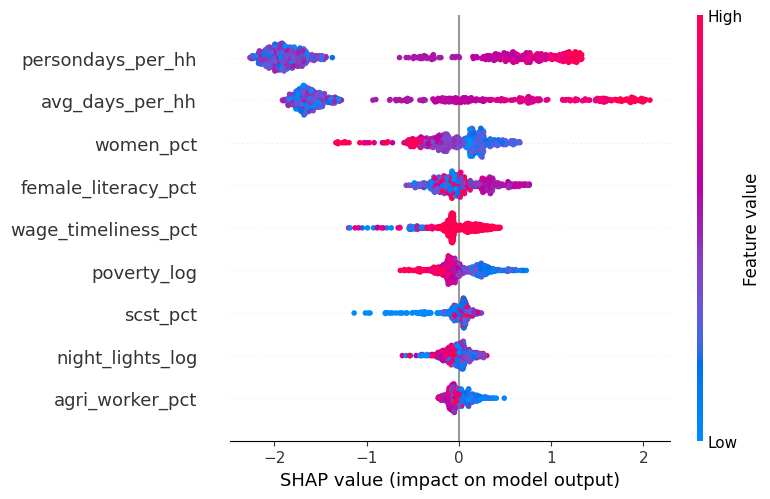

In [60]:
target_class = 0

shap.summary_plot(
    shap_values_full[:, :, target_class],
    X_full
)

SHAP analysis indicates that implementation variables dominate structural variables in explaining district governance archetypes. Women’s participation, average days of employment per household, persondays generated per household, and wage timeliness collectively contribute substantially more to tier assignment than poverty, literacy, SC/ST composition, or night-time luminosity. This suggests that differences in programme execution are more strongly associated with district governance typologies than underlying structural conditions.

In [61]:
top5 = (
    master
    .sort_values(
        "DWEI_score",
        ascending=False
    )
    .head(5)
)

top5[
    [
        "State",
        "District",
        "DWEI_score",
        "tier"
    ]
]

,State,District,DWEI_score,tier
274,Madhya Pradesh,Alirajpur,1.230911,Tier I - High Impact Districts
22,Arunachal Pradesh,Lohit,1.156015,Tier I - High Impact Districts
476,Rajasthan,Udaipur,1.099794,Tier I - High Impact Districts
578,Uttar Pradesh,Jaunpur,1.074459,Tier I - High Impact Districts
280,Madhya Pradesh,Bhind,1.055766,Tier I - High Impact Districts


In [42]:
bottom5 = (
    master
    .sort_values(
        "DWEI_score"
    )
    .head(5)
)

bottom5[
    [
        "State",
        "District",
        "DWEI_score",
        "tier"
    ]
]

,State,District,DWEI_score,tier
98,Chhattisgarh,Bijapur,-1.685924,Tier IV - Improvement Potential Districts
185,Jammu And Kashmir,Anantnag,-1.682968,Tier IV - Improvement Potential Districts
188,Jammu And Kashmir,Budgam,-1.341702,Tier IV - Improvement Potential Districts
190,Jammu And Kashmir,Ganderbal,-1.340841,Tier IV - Improvement Potential Districts
426,Punjab,Bathinda,-1.182837,Tier III - Inclusive Development Districts


In [62]:
master.groupby("tier").head(1)[
    [
        "State",
        "District",
        "tier",
        "DWEI_score"
    ]
]

,State,District,tier,DWEI_score
0,Andaman And Nicobar Islands,Nicobars,Tier V - Special Challenge Districts,-0.572450
1,Andaman And Nicobar Islands,North And Middle Andaman,Tier II - Strong Performing Districts,0.758327
3,Andhra Pradesh,Ananthapuramu,Tier I - High Impact Districts,-0.357821
5,Andhra Pradesh,East Godavari,Tier IV - Improvement Potential Districts,-0.014423
63,Bihar,Begusarai,Tier III - Inclusive Development Districts,-0.226896


In [63]:
def explain_district(
    district_name
):

    idx = master[
        master["District"] == district_name
    ].index[0]

    row = master.loc[idx]

    print("="*60)
    print(row["District"])
    print(row["State"])
    print(row["tier"])
    print("DWEI:", round(row["DWEI_score"], 3))
    print("="*60)

    model_idx = model_df.index.get_loc(idx)

    class_id = model.predict(
        X_full.iloc[[model_idx]]
    )[0]

    contrib = pd.DataFrame({
        "feature": features,
        "shap": shap_values_full[
            model_idx,
            :,
            class_id
        ]
    })

    contrib = contrib.sort_values(
        "shap",
        ascending=False
    )

    print(contrib)

In [64]:
explain_district(
    "Alirajpur"
)

Alirajpur
Madhya Pradesh
Tier I - High Impact Districts
DWEI: 1.231
               feature      shap
6      avg_days_per_hh  1.406826
8    persondays_per_hh  1.154846
7            women_pct  0.478399
5  wage_timeliness_pct  0.299846
2      agri_worker_pct  0.241759
4     night_lights_log  0.106164
1             scst_pct  0.088048
0  female_literacy_pct -0.225624
3          poverty_log -0.228618


In [66]:
master.groupby("tier")[
    [
        "women_pct",
        "avg_days_per_hh",
        "persondays_per_hh",
        "wage_timeliness_pct",
        "DWEI_score"
    ]
].mean().round(2)

,women_pct,avg_days_per_hh,persondays_per_hh,wage_timeliness_pct,DWEI_score
tier,,,,,
Tier I - High Impact Districts,46.79,43.08,43.58,99.74,0.28
Tier II - Strong Performing Districts,40.58,27.31,27.80,97.86,0.20
Tier III - Inclusive Development Districts,77.32,29.33,29.82,99.36,-0.12
Tier IV - Improvement Potential Districts,46.42,34.24,34.74,98.72,-0.42
Tier V - Special Challenge Districts,30.21,20.24,20.62,35.11,-0.34


# DWEI Governance Archetype Analysis (Notebook 04 & 05)

## Overview

Districts were grouped into governance archetypes using K-Means clustering on:

- DWEI Score
- Wage Timeliness (%)
- Average Days of Employment per Household
- Women Participation (%)
- Persondays per Household

The objective was not merely to classify districts as "good" or "bad", but to identify distinct patterns of welfare delivery and implementation behavior.

---

# Key Finding

The strongest drivers of district governance archetypes are **implementation factors**, not structural disadvantages.

SHAP analysis shows that MGNREGS implementation indicators contribute substantially more to tier assignment than poverty, literacy, SC/ST composition, or night-time luminosity.

---

# Global SHAP Feature Importance

| Rank | Feature | Mean SHAP Importance |
|--------|--------|--------:|
| 1 | women_pct | 0.831 |
| 2 | avg_days_per_hh | 0.739 |
| 3 | persondays_per_hh | 0.567 |
| 4 | wage_timeliness_pct | 0.540 |
| 5 | poverty_log | 0.167 |
| 6 | agri_worker_pct | 0.140 |
| 7 | female_literacy_pct | 0.129 |
| 8 | scst_pct | 0.115 |
| 9 | night_lights_log | 0.085 |

---

# Governance Archetypes

## Tier I – High Impact Districts

### Characteristics

- Highest DWEI scores
- Highest employment generation
- Highest work intensity
- Near-perfect wage timeliness
- Strong female participation

### Average Profile

| Indicator | Value |
|------------|-------:|
| Women Participation (%) | 46.79 |
| Avg Days per HH | 43.08 |
| Persondays per HH | 43.58 |
| Wage Timeliness (%) | 99.74 |
| DWEI Score | 0.28 |

### Interpretation

These districts convert programme implementation into measurable welfare improvements more effectively than other districts.

---

## Tier II – Strong Performing Districts

### Characteristics

- Positive DWEI scores
- Good implementation quality
- Strong but not exceptional employment generation
- High wage timeliness

### Average Profile

| Indicator | Value |
|------------|-------:|
| Women Participation (%) | 40.58 |
| Avg Days per HH | 27.31 |
| Persondays per HH | 27.80 |
| Wage Timeliness (%) | 97.86 |
| DWEI Score | 0.20 |

### Interpretation

These districts demonstrate consistent welfare delivery and positive outcomes, though not at the level of Tier I districts.

---

## Tier III – Inclusive Development Districts

### Characteristics

- Extremely high female participation
- Moderate employment generation
- Strong wage timeliness
- Moderate welfare outcomes

### Average Profile

| Indicator | Value |
|------------|-------:|
| Women Participation (%) | 77.32 |
| Avg Days per HH | 29.33 |
| Persondays per HH | 29.82 |
| Wage Timeliness (%) | 99.36 |
| DWEI Score | -0.12 |

### Interpretation

These districts excel in social inclusion and women’s participation, but high inclusion alone does not necessarily translate into the strongest welfare outcome improvements.

---

## Tier IV – Improvement Potential Districts

### Characteristics

- Reasonable implementation effort
- Moderate employment generation
- High wage timeliness
- Lower-than-expected welfare gains

### Average Profile

| Indicator | Value |
|------------|-------:|
| Women Participation (%) | 46.42 |
| Avg Days per HH | 34.24 |
| Persondays per HH | 34.74 |
| Wage Timeliness (%) | 98.72 |
| DWEI Score | -0.42 |

### Interpretation

These districts appear to deliver programmes reasonably well but struggle to convert implementation effort into proportional welfare improvements.

This suggests the presence of a **delivery–outcome gap**.

---

## Tier V – Special Challenge Districts

### Characteristics

- Very low wage timeliness
- Low employment generation
- Low programme intensity
- Predominantly remote, geographically constrained, or administratively unique districts

### Average Profile

| Indicator | Value |
|------------|-------:|
| Women Participation (%) | 30.21 |
| Avg Days per HH | 20.24 |
| Persondays per HH | 20.62 |
| Wage Timeliness (%) | 35.11 |
| DWEI Score | -0.34 |

### Interpretation

These districts operate under distinct geographic, demographic, or administrative constraints and therefore should not automatically be interpreted as governance failures.

---

# Major Findings

## Finding 1: Implementation Matters More Than Structural Conditions

The four most influential variables in determining district governance archetypes are:

1. Women Participation (%)
2. Average Days per Household
3. Persondays per Household
4. Wage Timeliness (%)

All four are implementation-related indicators.

---

## Finding 2: Employment Generation Is Strongly Associated With Higher Governance Performance

Higher-performing districts consistently generate:

- More employment days
- More persondays
- Better wage payment performance

than lower-performing districts.

---

## Finding 3: Women's Participation Is a Major Differentiator

Women participation emerged as the single most important variable in explaining governance archetypes nationally.

---

## Finding 4: Inclusion Does Not Automatically Guarantee Highest Welfare Gains

Tier III districts demonstrate that very high female participation can coexist with only moderate welfare outcome improvements.

---

## Finding 5: Delivery–Outcome Gaps Exist

Tier IV districts exhibit substantial implementation effort but comparatively weak welfare outcome gains, suggesting that programme delivery alone may not be sufficient to achieve welfare improvements.

---

# Model Validation

## Clustering

- Algorithm: K-Means
- Number of Clusters: 5
- Best Silhouette Score: ~0.26

## Hierarchical Validation

- Method: Ward Linkage
- Adjusted Rand Index (ARI): 0.41

### Interpretation

The moderate agreement between K-Means and Hierarchical Clustering suggests that district governance patterns form a continuum rather than sharply separated groups.

---

## XGBoost Validation

### Performance

| Metric | Value |
|----------|------:|
| Accuracy | 0.76 |
| Macro F1 Score | 0.82 |

### Interpretation

District governance archetypes are highly predictable from the selected features, indicating that the identified clusters capture meaningful and systematic patterns rather than random variation.

---

# Final Conclusion

The DWEI framework suggests that differences in district governance performance are associated more strongly with implementation quality than with underlying structural disadvantage. Employment generation, work intensity, women’s participation, and wage timeliness emerge as the primary differentiators of governance archetypes across Indian districts.

The results indicate that effective programme execution can meaningfully distinguish district performance even when structural conditions differ substantially.

In [68]:
analysis_df = master[
    ["State", "District"] +
    features +
    ["tier"]
].dropna().copy()

analysis_df.reset_index(drop=True, inplace=True)

X_full = analysis_df[features]

In [69]:
model_idx = analysis_df[
    analysis_df["District"] == "Alirajpur"
].index[0]

print(model_idx)

265


In [70]:
class_id = model.predict(
    X_full.iloc[[model_idx]]
)[0]

print(class_id)

0


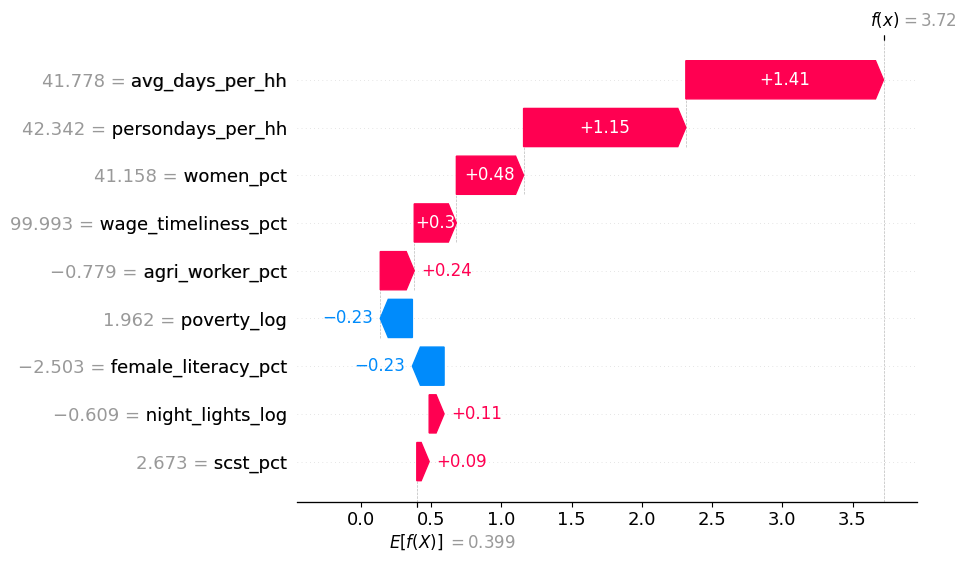

In [71]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_full[
            model_idx,
            :,
            class_id
        ],
        base_values=explainer.expected_value[class_id],
        data=X_full.iloc[model_idx],
        feature_names=features
    )
)

In [72]:
import joblib

joblib.dump(
    model,
    "../models/xgboost_tier_classifier.pkl"
)

['../models/xgboost_tier_classifier.pkl']

In [74]:
joblib.dump(
    le,
    "../models/tier_label_encoder.pkl"
)

['../models/tier_label_encoder.pkl']

In [75]:
features = [
    "female_literacy_pct",
    "scst_pct",
    "agri_worker_pct",
    "poverty_log",
    "night_lights_log",
    "wage_timeliness_pct",
    "avg_days_per_hh",
    "women_pct",
    "persondays_per_hh"
]

In [76]:
import json

with open(
    "../models/xgboost_features.json",
    "w"
) as f:
    json.dump(features, f)

In [78]:
rows = []

for i in range(len(X_full)):

    for class_id in range(5):

        row = {
            "district_idx": i,
            "tier_class": class_id
        }

        for j, feature in enumerate(features):
            row[feature] = shap_values_full[i, j, class_id]

        rows.append(row)

shap_df = pd.DataFrame(rows)

In [79]:
shap_df.shape

(3115, 11)

In [81]:
shap_df.to_parquet(
    "../shap_values/shap_values.parquet",
    index=False
)

In [86]:
master.to_parquet(
    "../data/master/master_final.parquet",
    index=False
)

In [87]:
analysis_df = master.dropna(
    subset=features + ["tier"]
).copy()

analysis_df = analysis_df.reset_index(drop=True)

In [88]:
district_explanations = []

for i in range(len(analysis_df)):

    class_id = model.predict(
        X_full.iloc[[i]]
    )[0]

    shap_row = shap_values_full[
        i,
        :,
        class_id
    ]

    temp = pd.DataFrame({
        "feature": features,
        "shap": shap_row
    })

    positive = (
        temp
        .sort_values("shap", ascending=False)
        .head(3)
    )

    negative = (
        temp
        .sort_values("shap", ascending=True)
        .head(3)
    )

    district_explanations.append({
        "State": analysis_df.iloc[i]["State"],
        "District": analysis_df.iloc[i]["District"],
        "tier": analysis_df.iloc[i]["tier"],

        "positive_1":
            f"{positive.iloc[0]['feature']} ({positive.iloc[0]['shap']:.2f})",

        "positive_2":
            f"{positive.iloc[1]['feature']} ({positive.iloc[1]['shap']:.2f})",

        "positive_3":
            f"{positive.iloc[2]['feature']} ({positive.iloc[2]['shap']:.2f})",

        "negative_1":
            f"{negative.iloc[0]['feature']} ({negative.iloc[0]['shap']:.2f})",

        "negative_2":
            f"{negative.iloc[1]['feature']} ({negative.iloc[1]['shap']:.2f})",

        "negative_3":
            f"{negative.iloc[2]['feature']} ({negative.iloc[2]['shap']:.2f})"
    })

In [90]:
district_explanations = pd.DataFrame(
    district_explanations
)
district_explanations.head()

,State,District,tier,positive_1,positive_2,positive_3,negative_1,negative_2,negative_3
0,Andaman And Nicobar Islands,Nicobars,Tier V - Special Challenge Districts,wage_timeliness_pct (3.90),agri_worker_pct (0.63),avg_days_per_hh (0.37),poverty_log (-0.10),night_lights_log (-0.06),female_literacy_pct (0.03)
1,Andaman And Nicobar Islands,North And Middle Andaman,Tier II - Strong Performing Districts,avg_days_per_hh (0.98),persondays_per_hh (0.62),night_lights_log (0.23),women_pct (-0.15),agri_worker_pct (-0.01),female_literacy_pct (0.03)
2,Andaman And Nicobar Islands,South Andamans,Tier II - Strong Performing Districts,avg_days_per_hh (1.00),persondays_per_hh (0.60),women_pct (0.31),poverty_log (-0.20),agri_worker_pct (-0.12),female_literacy_pct (-0.03)
3,Andhra Pradesh,Ananthapuramu,Tier I - High Impact Districts,avg_days_per_hh (1.91),persondays_per_hh (1.18),poverty_log (0.13),female_literacy_pct (-0.22),wage_timeliness_pct (-0.14),scst_pct (-0.06)
4,Andhra Pradesh,Chittoor,Tier I - High Impact Districts,avg_days_per_hh (1.21),persondays_per_hh (1.06),female_literacy_pct (0.47),women_pct (-0.29),agri_worker_pct (-0.09),poverty_log (0.00)


In [91]:
district_explanations.to_parquet(
    "../shap_values/district_explanations.parquet",
    index=False
)

district_explanations.to_csv(
    "../shap_values/district_explanations.csv",
    index=False
)

✓ XGBoost trained
✓ Evaluation completed
✓ Global SHAP completed
✓ Tier SHAP completed
✓ Waterfall plots completed
✓ shap_values.parquet saved
✓ District explanations generated
✓ District explanations saved